In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [2]:
wd = 0.642570281124498
wm = 1.0
tau = 100
tlist = np.linspace(0, tau, 200)
d = 0.1
N = 8

scar_dR = []
qubit_dR = []

# random diagonal with zero mean
for _ in range(200):
    Rtau = None
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, disorder=True, detuning=d, random_seed=True)
    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
    scar_dR.append(Rtau)

for _ in range(200):
    qH0, qH1 = get_qubit_ham(N, wm=1.0, disorder=True, detuning=d, random_seed=True)
    qeigvals, qeigstates = qH0.eigenstates()
    qband = qeigvals[-1] - qeigvals[0]

    qargs = {"A": 0.1, "omega": wm}
    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])

    qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
    qubit_dR.append(qRtau)

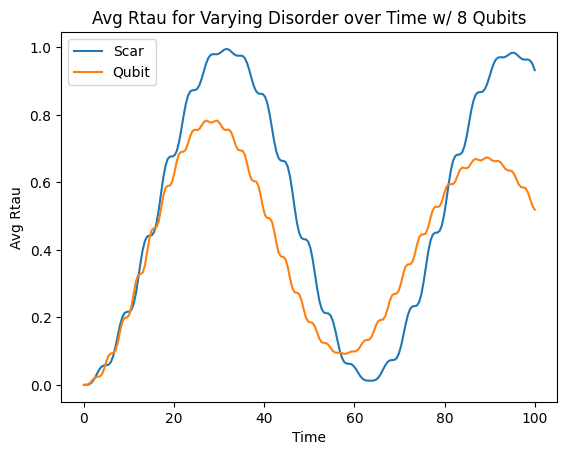

In [3]:
scar_dR = np.array(scar_dR)
plotScar = np.mean(scar_dR, axis=0)

qubit_dR = np.array(qubit_dR)
plotQubit = np.mean(qubit_dR, axis=0)

plt.plot(tlist, plotScar, label="Scar")
plt.plot(tlist, plotQubit, label="Qubit")
plt.title(f"Avg Rtau for Varying Disorder over Time w/ {N} Qubits")
plt.ylabel("Avg Rtau")
plt.xlabel("Time")
plt.legend()
plt.show()